In [1]:
from utils.logging import setup_root_logger
from utils.path_utils import get_project_root

logger = setup_root_logger()
root = get_project_root()

logger.info("""\n
    Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------
      
      Limitations:
      This model considers joint bleeds worsen the joints status (pettersson score), but not yet considers the relationship
      between joint damage and number of annual bleeding rate the patients experiences.
      Indeed several articles note that when a joint has been considered as a target joint, 
      there are more chance of repetitive hemarthrosis on that joint.
      So i suggest it will be a better simulation if the ABR some how be calculated dependent to arthropathy progression.
      This approach makes on-demand cheeper for short term and more expensive on long runs. 
      Also the patients overall simulated QALY and COSTs will be effected.
      This suggestion will not be implemented in this model and only proposed for further investigation.
""")

[20:19:23] INFO     

    Final Markov Model Structure

                                          <-----  Bleed Resolution  <-----
     -----------------------------------------------------------------------------------------------------------
     |                                                                                 |                       |
  [Healthy | Mild | Moderate | Severe] <Pettersson decremented utility reward> -> [LT_Bleeding] -> [Death]     |
     |                                                                                                         |
     |-----------------------------------------------> [Bleeding] ---------------------------------------------|
     |                                                                                                         |
      -----------------------------------------------> [Hemarthrosis] <Increment pettersson score> ------------

      Limitations:
      This model considers joint bleeds worsen the joints s

In [2]:
import pickle
from pathlib import Path

from app.analysis.distributions import Constant
from app.analysis.psa.parameter_resolver import ParameterResolver
from app.analysis.psa.parameters import Parameter
from app.analysis.psa.sampler import PSASampler
from app.domain.enums import Regime
from app.domain.scenario import Scenario
from app.notebook.parameter_sets import HemophiliaParamRepo
from app.notebook.scenario_helpers import define_scenario_extension, insert_scenario
from app.persistence.context import ModelContext

context = ModelContext.load()
param_repo = HemophiliaParamRepo(
    root=root, cache_path=Path("app/cache/samples.pkl"), context=context
)
with open(param_repo.root / param_repo.cache_path, "rb") as f:
    meta_samples = pickle.load(f)


# -----------------------------------
#        Base Scenario - CEA
# -----------------------------------
# baseline_age: disease recognition age in year
base_params = param_repo.load_psa_parameters()

# -----------------------------------
# Defining simulation scenarios | PSA
# -----------------------------------

scenarios = []

bayesian_scenario = [
    # Bayesian Meta-Analysis Scenario
    # Scenario Early On-Demand Bayesian (2-12 years)
    Scenario(
        name="early on-demand bayesian",
        regime=Regime.ON_DEMAND,
        overrides={
            "cycles": Parameter(distribution=Constant(value=10 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["on_demand"]["bayesian"],
            ),
        },
    ),
    # Scenario Early Prophylaxis Bayesian (2-12 years)
    Scenario(
        name="early prophylaxis bayesian",
        regime=Regime.PROPHYLAXIS,
        overrides={
            "cycles": Parameter(distribution=Constant(value=10 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["prophylaxis"]["bayesian"],
            ),
        },
    ),
    # Scenario Lifetime On-Demand Bayesian (2-100 years)
    Scenario(
        name="lifetime on-demand bayesian",
        regime=Regime.ON_DEMAND,
        overrides={
            "cycles": Parameter(distribution=Constant(98 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["on_demand"]["bayesian"],
            ),
        },
    ),
    # Scenario Lifetime Prophylaxis Bayesian (2-100 years)
    Scenario(
        name="lifetime prophylaxis bayesian",
        regime=Regime.PROPHYLAXIS,
        overrides={
            "cycles": Parameter(distribution=Constant(98 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["prophylaxis"]["bayesian"],
            ),
        },
    ),
]

dirichlet_scenarios = [
    # Dirichlet Meta-Analysis Scenario
    # Scenario Early On-Demand Dirichlet (2-12 years)
    Scenario(
        name="early on-demand dirichlet",
        regime=Regime.ON_DEMAND,
        overrides={
            "cycles": Parameter(distribution=Constant(value=10 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["on_demand"]["dirichlet"],
            ),
        },
    ),
    # Scenario Early Prophylaxis Dirichlet (2-12 years)
    Scenario(
        name="early prophylaxis dirichlet",
        regime=Regime.PROPHYLAXIS,
        overrides={
            "cycles": Parameter(distribution=Constant(value=10 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["prophylaxis"]["dirichlet"],
            ),
        },
    ),
    # Scenario Lifetime On-Demand Dirichlet (2-100 years)
    Scenario(
        name="lifetime on-demand dirichlet",
        regime=Regime.ON_DEMAND,
        overrides={
            "cycles": Parameter(distribution=Constant(98 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["on_demand"]["dirichlet"],
            ),
        },
    ),
    # Scenario Lifetime Prophylaxis Dirichlet (2-100 years)
    Scenario(
        name="lifetime prophylaxis dirichlet",
        regime=Regime.PROPHYLAXIS,
        overrides={
            "cycles": Parameter(distribution=Constant(98 * 52)),
            "bleeding_rate": Parameter(
                distribution=Constant(value=0),
                cache=meta_samples["prophylaxis"]["dirichlet"],
            ),
        },
    ),
]


insert_scenario(scenarios=scenarios, pair=bayesian_scenario)
insert_scenario(scenarios=scenarios, pair=dirichlet_scenarios)

# Probabilistic one-way perturbation (scenario analyses under probabilistic uncertainty)
# Discounting
insert_scenario(
    scenarios=scenarios,
    pair=define_scenario_extension(
        scenarios=bayesian_scenario,
        extensions={
            "is_discounting": {
                "benefits_discount_rate": Constant(
                    value=context.simulation.discounting.utility_rate_annual
                ),
                "costs_discount_rate": Constant(
                    value=context.simulation.discounting.cost_rate_annual
                ),
            }
        },
    ),
)
# Mean weight reduction by 10%
insert_scenario(
    scenarios=scenarios,
    pair=define_scenario_extension(
        scenarios=bayesian_scenario,
        extensions={
            "weight_reduction_10": {
                "weight_factor": Constant(value=0.9),
            }
        },
    ),
)
# Mean weight reduction by 20%
insert_scenario(
    scenarios=scenarios,
    pair=define_scenario_extension(
        scenarios=bayesian_scenario,
        extensions={
            "weight_reduction_20": {
                "weight_factor": Constant(value=0.8),
            }
        },
    ),
)
# Mean weight reduction by 30%
insert_scenario(
    scenarios=scenarios,
    pair=define_scenario_extension(
        scenarios=bayesian_scenario,
        extensions={
            "weight_reduction_30": {
                "weight_factor": Constant(value=0.7),
            }
        },
    ),
)

[20:19:23] INFO     Found 'auto' as default backend, checking available backends
[20:19:23] INFO     Matplotlib is available, defining as default backend
[20:19:24] INFO     arviz_base 1.2.0 available, exposing its functions as part of the `arviz` namespace
[20:19:24] INFO     arviz_stats 1.2.0 available, exposing its functions as part of the `arviz` namespace
[20:19:25] INFO     arviz_plots 1.2.0 available, exposing its functions as part of the `arviz` namespace
[20:19:25] INFO     Suppressed KeyError in PyTensorConfigParser.add for parameter 'cxx'!
[20:19:25] INFO     Suppressed KeyError in PyTensorConfigParser.add for parameter 'gcc_version_str'!
[20:19:25] INFO     Suppressed KeyError in PyTensorConfigParser.add for parameter 'compile__timeout'!
[20:19:25] INFO     Suppressed KeyError in PyTensorConfigParser.add for parameter 'DebugMode__check_c'!
[20:19:25] INFO     Suppressed KeyError in PyTensorConfigParser.add for parameter 'compiledir'!
[20:19:25] INFO     Suppressed KeyError 

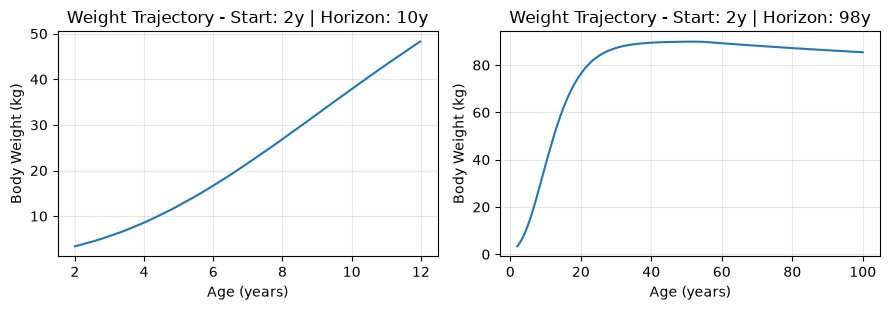

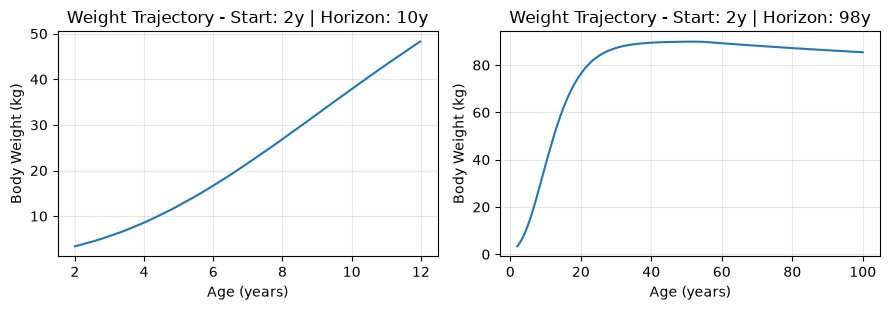

In [3]:
import numpy as np

from app.visualization.trajectories import plot_trajectories
from utils.math import cal_body_weight


# ---------------------------------
# Plotting weight gain function
# ---------------------------------
def weight_func(cycles: int, params: dict) -> np.ndarray:
    start_age = params["baseline_age"]
    return np.array([cal_body_weight(int(n), b=start_age) for n in range(cycles)])


plot_trajectories(
    scenarios=scenarios,
    default_scenario=base_params,
    trajectory_func=weight_func,
    y_label="Body Weight (kg)",
    title_prefix="Weight Trajectory - ",
)

# NOTE: Define 10-20-30 Weight reduction beside this graphs.

In [4]:
from app.domain.enums import HealthStates
from engine.chains import Chain

chains = []
states = [state.value for state in HealthStates]

# NOTE:
# Identity chain uses to introduce the states and matrix shape for further runtime calculation of transition matrix per individual patient.
# This matrix will be updated on patients growth adjusting with new transitions probabilities as the patients natural mortality rate changes over time.

identity_chain = Chain(
    name="main",
    states=states,
    matrix=np.eye(
        N=len(states), M=len(states), dtype=np.float64
    ),  # Identity matrix (Cubic)
)
print(f"\n{identity_chain.matrix} \n Identity matrix")
chains.append(identity_chain)


[[1. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 1.]] 
 Identity matrix


In [5]:
from app.domain.inputs import ModelInput
from app.domain.scenario import ScenarioBundle
from app.domain.worker import worker_function, worker_function_batch
from app.notebook.scenario_runner import run_scenarios_in_batches
from app.persistence.context import ModelContext
from utils import stable_hash

# Structure:
# ---------------------------------------------------
# PSA inputs ->
# Runner (Parallel orchestration) ->
# worker_function ->
# TransitionBuilder (ABR-> transition matrix) ->
# Markov Engine (Simulation per patient) ->
# Outputs
# ---------------------------------------------------


context = ModelContext.load()
seed = context.simulation.environment.seed
mode = context.simulation.environment.mode
sample_size = (
    context.simulation.psa.production
    if mode == "production"
    else context.simulation.psa.development
)

rng = np.random.default_rng(seed)

bundles: list[ScenarioBundle[ModelInput]] = []

# TODO: Replace with batch runner and store the production level result


for scenario in scenarios:
    scenario_seed = stable_hash(seed, scenario.name)
    scenario_params = scenario.apply_overrides(base_params)

    sampler = PSASampler(scenario_params, seed=scenario_seed)
    raw_samples = sampler.sample(sample_size)
    resolved_samples = ParameterResolver.resolve_samples(raw_samples)

    inputs = [
        ParameterResolver.build_single(resolved_samples, i) for i in range(sample_size)
    ]

    bundles.append(
        ScenarioBundle(
            scenario=scenario,
            inputs=inputs,
        )
    )

    logger.info(
        "Generated %d model inputs, bundled",
        len(inputs),
        extra={"scenario": scenario.name},
    )

[20:19:27] INFO     Generated 10000 model inputs, bundled | scenario=early on-demand bayesian
[20:19:27] INFO     Generated 10000 model inputs, bundled | scenario=early prophylaxis bayesian
[20:19:27] INFO     Generated 10000 model inputs, bundled | scenario=lifetime on-demand bayesian
[20:19:27] INFO     Generated 10000 model inputs, bundled | scenario=lifetime prophylaxis bayesian
[20:19:27] INFO     Generated 10000 model inputs, bundled | scenario=early on-demand dirichlet
[20:19:27] INFO     Generated 10000 model inputs, bundled | scenario=early prophylaxis dirichlet
[20:19:27] INFO     Generated 10000 model inputs, bundled | scenario=lifetime on-demand dirichlet
[20:19:28] INFO     Generated 10000 model inputs, bundled | scenario=lifetime prophylaxis dirichlet
[20:19:28] INFO     Generated 10000 model inputs, bundled | scenario=early on-demand bayesian is_discounting
[20:19:28] INFO     Generated 10000 model inputs, bundled | scenario=early prophylaxis bayesian is_discounting
[20:

In [6]:
run_scenarios_in_batches(
    bundles=bundles,
    context=context,
    batch_size=4,
    engine="batch",
    worker_function=worker_function,
    identity_chain=identity_chain,
    output_dir=root / "app/cache" / "psa" / "parquet",
    temp_dir=root / "app/cache" / "psa" / "temp" / "parquet_temp",
    batch_worker_function=worker_function_batch,
)

[20:19:29] INFO     Starting batch runner with 24 scenario, batch size: 4, engine: batch


[20:22:38] INFO     Saved temp batch 0 to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\temp\parquet_temp\batch_0.parquet
[20:22:38] INFO     Batch 1/6 complete (4 scenarios processed, 20 remaining). Elapsed=188.8s, avg_batch=188.8s, est_remaining=943.9s


[20:26:44] INFO     Saved temp batch 1 to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\temp\parquet_temp\batch_1.parquet
[20:26:44] INFO     Batch 2/6 complete (8 scenarios processed, 16 remaining). Elapsed=434.6s, avg_batch=217.3s, est_remaining=869.1s


[20:30:44] INFO     Saved temp batch 2 to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\temp\parquet_temp\batch_2.parquet
[20:30:44] INFO     Batch 3/6 complete (12 scenarios processed, 12 remaining). Elapsed=674.6s, avg_batch=224.9s, est_remaining=674.6s


[20:34:01] INFO     Saved temp batch 3 to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\temp\parquet_temp\batch_3.parquet
[20:34:01] INFO     Batch 4/6 complete (16 scenarios processed, 8 remaining). Elapsed=872.2s, avg_batch=218.0s, est_remaining=436.1s


[20:37:12] INFO     Saved temp batch 4 to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\temp\parquet_temp\batch_4.parquet
[20:37:12] INFO     Batch 5/6 complete (20 scenarios processed, 4 remaining). Elapsed=1062.6s, avg_batch=212.5s, est_remaining=212.5s


[20:40:19] INFO     Saved temp batch 5 to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\temp\parquet_temp\batch_5.parquet
[20:40:19] INFO     Batch 6/6 complete (24 scenarios processed, 0 remaining). Elapsed=1250.1s, avg_batch=208.4s, est_remaining=0.0s
[20:40:25] INFO     Combining 6 temp batch files into a DF for pairing
[20:40:26] INFO     Saved combined results checkpoint to C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\parquet\all_results_combined.parquet
[20:40:26] INFO     Saved Parquet for pair early on-demand bayesian vs early prophylaxis bayesian -> C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\parquet\early_on-demand_bayesian_vs_early_prophylaxis_bayesian.parquet
[20:40:26] INFO     Saved Parquet for pair lifetime on-demand bayesian vs lifetime prophylaxis bayesian -> C:\Users\Jino\Desktop\University\hemophilia\markov-chain-3-14\cache\psa\parquet\lifetime_on-demand_bayesian_vs_lifetime_prophylaxis_

[WindowsPath('C:/Users/Jino/Desktop/University/hemophilia/markov-chain-3-14/cache/psa/parquet/early_on-demand_bayesian_vs_early_prophylaxis_bayesian.parquet'),
 WindowsPath('C:/Users/Jino/Desktop/University/hemophilia/markov-chain-3-14/cache/psa/parquet/lifetime_on-demand_bayesian_vs_lifetime_prophylaxis_bayesian.parquet'),
 WindowsPath('C:/Users/Jino/Desktop/University/hemophilia/markov-chain-3-14/cache/psa/parquet/early_on-demand_dirichlet_vs_early_prophylaxis_dirichlet.parquet'),
 WindowsPath('C:/Users/Jino/Desktop/University/hemophilia/markov-chain-3-14/cache/psa/parquet/lifetime_on-demand_dirichlet_vs_lifetime_prophylaxis_dirichlet.parquet'),
 WindowsPath('C:/Users/Jino/Desktop/University/hemophilia/markov-chain-3-14/cache/psa/parquet/early_on-demand_bayesian_is_discounting_vs_early_prophylaxis_bayesian_is_discounting.parquet'),
 WindowsPath('C:/Users/Jino/Desktop/University/hemophilia/markov-chain-3-14/cache/psa/parquet/lifetime_on-demand_bayesian_is_discounting_vs_lifetime_proph

In [7]:
import pandas as pd

df = pd.read_parquet(
    root / "app/cache" / "psa" / "parquet" / "all_results_combined.parquet"
)
# Each scenario has `sample_size` rows, so divide total rows by sample_size to get scenario count
scenario_count = int(df.shape[0] / sample_size)
# Each pair has 2 scenarios (on-demand and prophylaxis), so divide by 2 to get pair count
scenario_pair_count = scenario_count // 2
# Each parameter scenario has 4 variations (base, low, high for both on-demand and prophylaxis), so divide by 4 to get unique parameter scenario count
scenario_param_count = scenario_count // 4
logger.info(
    "Total scenarios: %d, Total pairs: %d, Unique parameter scenarios: %d",
    scenario_count,
    scenario_pair_count,
    scenario_param_count,
)

[20:40:27] INFO     Total scenarios: 24, Total pairs: 12, Unique parameter scenarios: 6
